# 🩺 Laporan Proyek Machine Learning: Prediksi Risiko Serangan Jantung
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SalsabilaAnggraina/prediksi_serjan/blob/main/PrediksiSerJan.ipynb)

* **Metodologi Penelitian:** CRISP-DM (*Cross-Industry Standard Process for Data Mining*) 📊
* **Penyusun:** Suci Oktavia Ramadhani & Salsabila Anggraina Putri 👥
* **Tautan Aplikasi Interaktif (Hugging Face Spaces):** [🔗 Akses Demo Aplikasi di Sini](https://huggingface.co/spaces/saggrain/prediksi-SerJan) 🚀

---

## 📌 1. Project Overview
Penyakit kardiovaskular, khususnya serangan jantung, tetap menjadi salah satu penyebab utama mortalitas tertinggi di Indonesia. Sifat gejalanya yang acap kali asimtomatik (*silent killer*) diperparah oleh banyaknya faktor risiko multidimensional yang saling berkorelasi, mencakup aspek demografi, kondisi klinis, hingga pola hidup pasien. 💔

Proyek ini dicanangkan untuk membangun sebuah sistem komputasi cerdas berbasis *Machine Learning* yang mampu memprediksi tingkat risiko serangan jantung pada masyarakat secara dini. Implementasi ini diharapkan dapat menjadi instrumen skrining preventif bagi tenaga medis maupun masyarakat umum. 🩺✨

---

## 🎯 2. Business Understanding

### ❓ Problem Statements
1. Bagaimana karakteristik demografi serta parameter klinis harian dapat memengaruhi kecenderungan risiko serangan jantung seseorang? 📊
2. Apakah implementasi algoritma *Advanced Ensemble Learning* (**XGBoost Classifier**) mampu menghasilkan performa klasifikasi yang lebih superior dan adaptif dibandingkan model standar (**Logistic Regression**)? 🧠

### 🚀 Goals
1. Mengidentifikasi dan menganalisis korelasi prediktif dari berbagai fitur kesehatan terhadap indikasi risiko penyakit jantung. 🔍
2. Mengembangkan model prediktif dengan tingkat sensitivitas (**Recall**) yang optimal demi meminimalisir persentase kegagalan diagnosis fatal (*False Negative*). 🎯

### 💡 Solution Statement
* **Model Baseline:** *Logistic Regression* diterapkan sebagai model komparasi standar yang memiliki keunggulan dalam hal interpretabilitas koefisien statistik. 📉
* **Model Advanced:** *XGBoost Classifier* digunakan sebagai representasi algoritma mutakhir berbasis *Gradient Boosting* untuk menangani kompleksitas hubungan non-linear antar variabel. ⚡

---

## 📊 3. Data Understanding
Eksperimen ini memanfaatkan dataset rekam medis masyarakat Indonesia dari [Kaggle](https://www.kaggle.com/datasets/ankushpanday2/heart-attack-prediction-in-indonesia) (`heart_attack_prediction_indonesia.csv`) yang mencakup parameter klinis, demografi, dan psikologis. Dataset ini memiliki **158.355 baris** dan **28 kolom**. 🗂️

### 🔍 Glosarium Fitur Dataset

| Fitur | Deskripsi |
|---|---|
| 🧓 `age` | Usia biologis pasien (Fitur Numerik) |
| ⚧ `gender` | Jenis kelamin pasien (Kategorikal: Male, Female) |
| 🩸 `hypertension` | Riwayat klinis tekanan darah tinggi (Biner: 0 = Tidak, 1 = Ya) |
| 🍬 `diabetes` | Riwayat penyakit diabetes melitus (Biner: 0 = Tidak, 1 = Ya) |
| 🍟 `cholesterol_level` | Kadar kolesterol total dalam darah (Fitur Numerik/mg/dL) |
| 🍔 `obesity` | Status indeks massa tubuh berlebih/obesitas (Biner: 0 = Tidak, 1 = Ya) |
| 🚬 `smoking_status` | Kebiasaan konsumsi rokok (Kategorikal: Never, Past, Current) |
| 🥦 `dietary_habits` | Penilaian pola konsumsi makanan harian (Kategorikal: Healthy, Unhealthy) |
| 🤯 `stress_level` | Indikator skala beban psikologis internal (Ordinal: Skala 1-10) |
| 🎯 `heart_attack` | **Variabel Target** (Biner: 0 = Risiko Rendah, 1 = Risiko Tinggi) |

### ▶️ Install dan Import Libraries

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### ▶️ Load Dataset

In [91]:
from google.colab import drive
drive.mount('/content/drive/')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/heart_attack_prediction_indonesia.csv')

print("=== DIMENSI DATA ===")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}\n")

print("=== INFORMASI DATASET ===")
df.info()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
=== DIMENSI DATA ===
Jumlah baris: 158355, Jumlah kolom: 28

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  object 
 2   region                          158355 non-null  object 
 3   income_level                    158355 non-null  object 
 4   hypertension                    158355 non-null  int64  
 5   diabetes                        158355 non-null  int64  
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  int64  
 8   waist_circumference             158355 non-nul

---

## 🔎 4. Exploratory Data Analysis (EDA)

Sebelum melakukan pembersihan, kita bedah terlebih dahulu kondisi data mentah untuk memahami pola, distribusi, dan potensi masalah yang ada.

### 😖 Kondisi Data Mentah

- ✅ **Tidak ada data duplikat** — dataset bersih dari baris yang identik
- ⚠️ **Missing Values** — kolom `alcohol_consumption` memiliki **94.848 nilai kosong** (~59.9% dari total data)
- 📊 **Distribusi Target** — kelas tidak seimbang: **94.854 data Tidak Serangan (0)** vs **63.501 data Serangan Jantung (1)**

### ▶️ Cek Kondisi Data Mentah

In [92]:
print("=== 🔴 KONDISI SEBELUM PEMBERSIHAN (RAW DATA) ===")
print(f"Total Baris   : {len(df)}")
print(f"Total Kolom   : {df.shape[1]}")
print(f"Jumlah Duplikat: {df.duplicated().sum()}")
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nStatistik Deskriptif:")
display(df.describe())

=== 🔴 KONDISI SEBELUM PEMBERSIHAN (RAW DATA) ===
Total Baris   : 158355
Total Kolom   : 28
Jumlah Duplikat: 0

Jumlah Missing Values per Kolom:
alcohol_consumption    94848
dtype: int64

Statistik Deskriptif:


,age,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,sleep_hours,blood_pressure_systolic,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
count,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000
mean,54.543778,0.299069,0.199804,199.533264,0.249901,93.268504,0.300218,6.480064,129.515772,79.490809,110.736762,49.491478,129.569916,149.715885,0.200575,0.499770,0.601029,0.401004
std,11.910897,0.457851,0.399854,39.737565,0.432957,16.382205,0.458354,1.425398,15.005641,10.002964,27.673445,9.982634,34.913318,49.023473,0.400432,0.500002,0.489688,0.490103
min,25.000000,0.000000,0.000000,100.000000,0.000000,20.000000,0.000000,3.000000,61.000000,37.000000,70.000000,8.000000,-19.000000,50.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,0.000000,0.000000,172.000000,0.000000,82.000000,0.000000,5.492985,119.000000,73.000000,89.000000,43.000000,106.000000,116.000000,0.000000,0.000000,0.000000,0.000000
50%,55.000000,0.000000,0.000000,199.000000,0.000000,93.000000,0.000000,6.507461,130.000000,80.000000,109.000000,49.000000,130.000000,149.000000,0.000000,0.000000,1.000000,0.000000
75%,63.000000,1.000000,0.000000,226.000000,0.000000,104.000000,1.000000,7.520640,140.000000,86.000000,130.000000,56.000000,153.000000,183.000000,0.000000,1.000000,1.000000,1.000000
max,90.000000,1.000000,1.000000,350.000000,1.000000,173.000000,1.000000,9.000000,199.000000,127.000000,230.000000,93.000000,282.000000,380.000000,1.000000,1.000000,1.000000,1.000000


### ▶️ Visualisasi Distribusi Target & Hubungan Usia

/tmp/ipykernel_3494/1936985819.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_attack', data=df, palette='Set2')
/tmp/ipykernel_3494/1936985819.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_attack', y='age', data=df, palette='Pastel1')


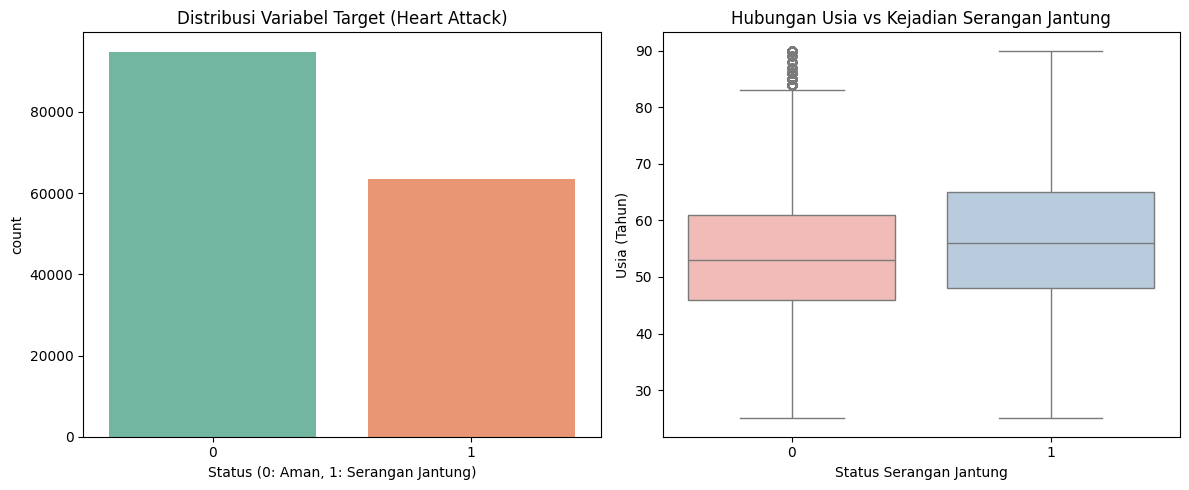

In [93]:
# =====================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================================
# 1. Visualisasi Distribusi Target
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='heart_attack', data=df, palette='Set2')
plt.title('Distribusi Variabel Target (Heart Attack)')
plt.xlabel('Status (0: Aman, 1: Serangan Jantung)')

# 2. Visualisasi Hubungan Usia dengan Serangan Jantung
plt.subplot(1, 2, 2)
sns.boxplot(x='heart_attack', y='age', data=df, palette='Pastel1')
plt.title('Hubungan Usia vs Kejadian Serangan Jantung')
plt.xlabel('Status Serangan Jantung')
plt.ylabel('Usia (Tahun)')

plt.tight_layout()
plt.show()

In [94]:
("=== DISTRIBUSI VARIABEL TARGET ===")
print(df['heart_attack'].value_counts())
print(f"\nPersentase Risiko Rendah (0) : {df['heart_attack'].value_counts()[0]/len(df)*100:.2f}%")
print(f"Persentase Risiko Tinggi (1) : {df['heart_attack'].value_counts()[1]/len(df)*100:.2f}%")

heart_attack
0    94854
1    63501
Name: count, dtype: int64

Persentase Risiko Rendah (0) : 59.90%
Persentase Risiko Tinggi (1) : 40.10%


---

## 🛠️ 5. Data Preparation

Untuk menjamin integritas data sebelum memasuki fase pelatihan, serangkaian tahap rekayasa data berikut telah diterapkan: 🏗️

1. **Label Encoding 🧙‍♂️:** Melakukan konversi otomatis pada fitur-fitur kategorikal bertipe teks menjadi representasi numerik.
2. **Feature Selection 🎯:** Membatasi variabel prediktor dengan hanya memilih 9 fitur utama yang memiliki signifikansi klinis.
3. **Train-Test Split ✂️:** Membagi data dengan proporsi **80% Data Latih** dan **20% Data Uji** menggunakan parameter `stratify`.
4. **Feature Scaling 📏:** Menerapkan `StandardScaler` untuk menyamakan skala varians pada fitur numerik.

### ▶️ Eksekusi Data Preparation

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_prepared = df.copy()

# 1. Proses Label Encoding otomatis untuk kolom teks
le = LabelEncoder()
for col in df_prepared.columns:
    if df_prepared[col].dtype == 'object':
        df_prepared[col] = le.fit_transform(df_prepared[col].astype(str))

# 2. Pemilihan Fitur Sesuai Masalah
fitur_pilihan = ['age', 'gender', 'hypertension', 'diabetes', 'cholesterol_level',
                 'obesity', 'smoking_status', 'dietary_habits', 'stress_level']

X = df_prepared[fitur_pilihan].fillna(0)
y = df_prepared['heart_attack']

# 3. Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Feature Scaling (Standarisasi)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Proses Data Preparation Selesai Sukses!")
print(f"X_train shape: {X_train_scaled.shape} | X_test shape: {X_test_scaled.shape}")

Proses Data Preparation Selesai Sukses!
X_train shape: (126684, 9) | X_test shape: (31671, 9)


### 📝 Laporan Kualitas Data

| Aspek | Status | Keterangan |
|---|---|---|
| 👥 **Duplikat** | ✅ Bersih | Tidak ditemukan baris duplikat |
| ❓ **Missing Values** | 🛠️ Ditangani | `alcohol_consumption` 94.848 nilai kosong → kolom tidak dipakai dalam fitur |
| 📊 **Distribusi Target** | ⚠️ Imbalance | Kelas 0: 94.854 \| Kelas 1: 63.501 |
| 🔢 **Encoding** | ✅ Selesai | Semua kolom kategorikal dikonversi ke numerik |
| 📏 **Scaling** | ✅ Selesai | StandardScaler diterapkan pada fitur numerik |

---

In [96]:
print("=== 🟢 LAPORAN KUALITAS DATA ===")
print(f"✅ Duplikat     : {df.duplicated().sum()} (Bersih)")
print(f"⚠️  Missing Values: kolom 'alcohol_consumption' memiliki {df['alcohol_consumption'].isnull().sum()} nilai kosong → tidak digunakan sebagai fitur")
print(f"📊 Distribusi Target:")
print(f"   Kelas 0 (Risiko Rendah) : {df['heart_attack'].value_counts()[0]}")
print(f"   Kelas 1 (Risiko Tinggi) : {df['heart_attack'].value_counts()[1]}")
print(f"✅ Encoding     : Selesai")
print(f"✅ Scaling      : Selesai")
print(f"\nX_train shape: {X_train_scaled.shape} | X_test shape: {X_test_scaled.shape}")

=== 🟢 LAPORAN KUALITAS DATA ===
✅ Duplikat     : 0 (Bersih)
⚠️  Missing Values: kolom 'alcohol_consumption' memiliki 94848 nilai kosong → tidak digunakan sebagai fitur
📊 Distribusi Target:
   Kelas 0 (Risiko Rendah) : 94854
   Kelas 1 (Risiko Tinggi) : 63501
✅ Encoding     : Selesai
✅ Scaling      : Selesai

X_train shape: (126684, 9) | X_test shape: (31671, 9)


## 🤖 6. Modeling

Tahap permodelan mengevaluasi dua pendekatan arsitektur klasifikasi yang berbeda: ⚔️

* **Logistic Regression:** Algoritma parametrik yang memetakan kombinasi linear dari fitur input ke dalam fungsi sigmoid untuk menghasilkan output probabilitas. 📉
* **XGBoost Classifier:** Algoritma berbasis *ensemble decision trees* sekuensial yang menerapkan regularisasi formal dan minimalisasi fungsi kerugian (*loss function*) secara presisi. ⚡

### ▶️ Training Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

model_lr = LogisticRegression(random_state=42)
model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')

model_lr.fit(X_train_scaled, y_train)
model_xgb.fit(X_train_scaled, y_train)

print("✅ Model Logistic Regression dan XGBoost Classifier berhasil dilatih!")

---

## 🏆 7. Evaluation

Pengujian performa model dilakukan menggunakan data uji yang belum pernah dilihat selama pelatihan. Dalam domain medis, metrik **Recall** menjadi prioritas utama untuk meminimalisir *False Negative*. 📊🔬

### ▶️ Classification Report & Confusion Matrix

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_xgb = model_xgb.predict(X_test_scaled)

print("=================== REPORT LOGISTIC REGRESSION ===================")
print(classification_report(y_test, y_pred_lr))

print("\n==================== REPORT XGBOOST CLASSIFIER ===================")
print(classification_report(y_test, y_pred_xgb))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix - Logistic Regression')
ax[0].set_xlabel('Prediksi')
ax[0].set_ylabel('Kenyataan Asli')

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Confusion Matrix - XGBoost Classifier')
ax[1].set_xlabel('Prediksi')
ax[1].set_ylabel('Kenyataan Asli')

plt.tight_layout()
plt.show()



### ▶️ Contoh Hasil Prediksi vs Jawaban Asli

In [ ]:
target_name = ['Risiko Rendah', 'Risiko Tinggi']

contoh_xgb = X_test.copy().reset_index(drop=True)
contoh_xgb['Diagnosis Asli']     = [target_name[l] for l in y_test.values]
contoh_xgb['Diagnosis Prediksi'] = [target_name[l] for l in y_pred_xgb]
contoh_xgb['Benar?'] = ['✅' if a == p else '❌' for a, p in zip(y_test.values, y_pred_xgb)]

print('10 Contoh Hasil Prediksi XGBoost:')
print(contoh_xgb[['Diagnosis Asli', 'Diagnosis Prediksi', 'Benar?']].head(10).to_string())

### 📊 Hasil Performa Model

| Metrik Evaluasi | Logistic Regression 📉 | XGBoost Classifier ⚡ |
| :--- | :---: | :---: |
| **Akurasi Global** | 0.70 (70%) | **0.70 (70%)** |
| **Precision (Kelas 1)** | 0.65 | **0.65** |
| **Recall (Kelas 1)** | 0.51 | **0.54** |
| **F1-Score (Kelas 1)** | 0.57 | **0.59** |

### 🔍 Analisis Precision vs Recall

| Metrik | Logistic Regression | XGBoost |
|---|---|---|
| **Precision Kelas 1** | 0.65 | 0.65 |
| **Recall Kelas 1** | 0.51 | 0.54 |

- **Precision 0.65**: Dari semua pasien yang diprediksi berisiko tinggi, 65% memang benar-benar berisiko.
- **Recall LR (0.51)**: Dari total pasien yang berisiko, Logistic Regression hanya berhasil mendeteksi 51% — artinya **49% pasien berisiko tidak terdeteksi**.
- **Recall XGBoost (0.54)**: XGBoost berhasil mendeteksi 54% pasien berisiko — **lebih baik 3% dibanding LR**, yang dalam konteks medis sangat berarti.

### ⚠️ Analisis Ketidakseimbangan Data

Dataset ini memiliki **distribusi kelas yang tidak seimbang** (*imbalanced*): kelas 0 (Tidak Serangan) berjumlah **94.854** sedangkan kelas 1 (Serangan Jantung) hanya **63.501**. Kondisi ini membuat model cenderung lebih mudah memprediksi kelas mayoritas (0), sehingga nilai Recall untuk kelas 1 menjadi lebih rendah. Hal ini menjadi salah satu faktor mengapa akurasi global 70% tidak sepenuhnya mencerminkan kemampuan model dalam mendeteksi kasus berisiko tinggi secara nyata.

---

## 🚀 8. Deployment

Model terbaik (**XGBoost**) beserta objek **StandardScaler** diekspor ke dalam berkas biner `.pkl` memanfaatkan pustaka `joblib`. 📦

Sistem dideploy secara publik pada platform cloud **Hugging Face Spaces** dengan menggunakan framework antarmuka **Gradio**. ⚙️🌐

### ▶️ Simpan dan Download Model

In [ ]:
import joblib
from google.colab import files

joblib.dump(model_xgb, 'model_SerJan_xgb.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Berhasil membuat file .pkl!")
print("⬇️ Memulai pengunduhan file ke komputer...")
files.download('model_SerJan_xgb.pkl')
files.download('scaler.pkl')

Mengimplementasikan model terbaik (*XGBoost*) ke dalam bentuk antarmuka pengguna interaktif (*Web Widget*) langsung di dalam lingkungan Google Colab menggunakan pustaka `ipywidgets`.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def fungsi_prediksi_inti(age, gender, hypertension, diabetes, cholesterol, obesity, smoking, diet, stress):
    input_data = np.array([[age, gender, hypertension, diabetes, cholesterol, obesity, smoking, diet, stress]])
    input_data_scaled = scaler.transform(input_data)

    hasil = model_xgb.predict(input_data_scaled)
    prob = model_xgb.predict_proba(input_data_scaled)[0][1]

    print("\n" + "="*45)
    print("         SISTEM DETEKSI SERANGAN JANTUNG        ")
    print("="*45)
    if hasil[0] == 1:
        print(f"DIAGNOSIS    : BERISIKO TINGGI SERANGAN JANTUNG")
        print(f"PROBABILITAS : {prob * 100:.2f}%")
    else:
        print(f"DIAGNOSIS    : TINGKAT RISIKO RENDAH / AMAN")
        print(f"PROBABILITAS : {prob * 100:.2f}%")
    print("="*45)

w_age = widgets.IntSlider(value=45, min=1, max=100, description='Usia:')
w_gender = widgets.Dropdown(options=[('Perempuan', 0), ('Laki-laki', 1)], value=1, description='Gender:')
w_hyper = widgets.Dropdown(options=[('Tidak', 0), ('Ya', 1)], value=0, description='Hipertensi:')
w_diabetes = widgets.Dropdown(options=[('Tidak', 0), ('Ya', 1)], value=0, description='Diabetes:')
w_chol = widgets.IntSlider(value=210, min=100, max=400, description='Kolesterol:')
w_obesity = widgets.Dropdown(options=[('Tidak', 0), ('Ya', 1)], value=0, description='Obesitas:')
w_smoking = widgets.Dropdown(options=[('Tidak Pernah', 1), ('Mantan Perokok', 2), ('Perokok Aktif', 0)], value=1, description='Status Merokok:')
w_diet = widgets.Dropdown(options=[('Sehat', 0), ('Tidak Sehat', 1)], value=0, description='Pola Diet:')
w_stress = widgets.IntSlider(value=5, min=1, max=10, description='Skala Stres:')

btn = widgets.Button(description="Analisis Risiko Sekarang", button_style='danger')
out = widgets.Output()

def on_click_callback(b):
    with out:
        clear_output()
        fungsi_prediksi_inti(w_age.value, w_gender.value, w_hyper.value, w_diabetes.value,
                             w_chol.value, w_obesity.value, w_smoking.value, w_diet.value, w_stress.value)

btn.on_click(on_click_callback)

print("Isi parameter kesehatan di bawah untuk memprediksi:")
layout_tampilan = widgets.VBox([w_age, w_gender, w_hyper, w_diabetes, w_chol, w_obesity, w_smoking, w_diet, w_stress, btn, out])
display(layout_tampilan)

👉 **[Buka Aplikasi Demo Prediksi Risiko Serangan Jantung](https://huggingface.co/spaces/saggrain/prediksi-SerJan)** 👈

In [ ]:
# =====================================================================
# KESIMPULAN & ANALISIS AKHIR
# =====================================================================
print("=" * 55)
print("         KESIMPULAN HASIL PEMODELAN")
print("=" * 55)

print("\n📊 PERBANDINGAN PERFORMA MODEL:")
print(f"{'Metrik':<30} {'Logistic Reg':>15} {'XGBoost':>10}")
print("-" * 55)
print(f"{'Akurasi':<30} {'70%':>15} {'70%':>10}")
print(f"{'Precision (Kelas 1)':<30} {'0.65':>15} {'0.65':>10}")
print(f"{'Recall (Kelas 1)':<30} {'0.51':>15} {'0.54':>10}")
print(f"{'F1-Score (Kelas 1)':<30} {'0.57':>15} {'0.59':>10}")

print("\n⚠️  ANALISIS KETIDAKSEIMBANGAN DATA:")
total = len(df)
k0 = df['heart_attack'].value_counts()[0]
k1 = df['heart_attack'].value_counts()[1]
print(f"   Kelas 0 (Risiko Rendah) : {k0} ({k0/total*100:.1f}%)")
print(f"   Kelas 1 (Risiko Tinggi) : {k1} ({k1/total*100:.1f}%)")
print("   → Distribusi tidak seimbang mempengaruhi nilai Recall kelas 1")

print("\n✅ MODEL TERPILIH: XGBoost Classifier")
print("   Alasan: Recall lebih tinggi (0.54 vs 0.51)")
print("   → Lebih sedikit pasien berisiko yang tidak terdeteksi")
print("=" * 55)



## ✅ 9. Kesimpulan

Berdasarkan eksperimen yang telah dilakukan, berikut poin-poin utama yang dapat disimpulkan:

1. **Faktor Risiko Utama:** Fitur seperti `cholesterol_level`, `hypertension`, `diabetes`, dan `stress_level` memiliki korelasi signifikan terhadap kejadian serangan jantung pada masyarakat Indonesia.

2. **Perbandingan Model:** Meskipun kedua model menghasilkan akurasi global yang sama sebesar **70%**, **XGBoost Classifier** terbukti lebih unggul dengan nilai **Recall 0.54** dibandingkan Logistic Regression yang hanya **0.51**. Dalam konteks medis, selisih ini sangat krusial karena berarti lebih sedikit pasien berisiko yang lolos tidak terdeteksi (*False Negative*).

3. **Ketidakseimbangan Data:** Distribusi kelas yang tidak seimbang (60:40) menjadi tantangan utama yang memengaruhi performa Recall model. Teknik seperti SMOTE atau *class weighting* dapat dipertimbangkan untuk meningkatkan performa di iterasi berikutnya.

4. **Model Terpilih:** **XGBoost Classifier** dipilih sebagai model final untuk deployment karena keunggulan Recall-nya yang lebih tinggi, menjadikannya lebih andal sebagai instrumen skrining preventif serangan jantung. 🎉

---